#### Example A
- We are going to use 2 layers
- optimizer we are going to use SGD
- We are going to use without Normalization

#### Example B
- We are going to use 3 layers
- optimizer we are going to use Adam
- We are going to use without Normalization

#### Example C
- We are going to use 2 layers
- optimizer we are going to use SGD
- We are going to use with Normalization and Standardization

In [100]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
insurance_data = pd.read_csv('/content/sample_data/insurance_data.csv')
insurance_data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [102]:
insurance_data_one_hot = pd.get_dummies(insurance_data)
insurance_data_one_hot.head(10)
#

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,True,False


In [103]:
X=insurance_data_one_hot.drop('charges',axis=1)
y=insurance_data_one_hot['charges']

In [104]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [105]:
tf.random.set_seed(42)
insurance_model=tf.keras. Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

In [106]:
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=['mae'])

In [107]:
insurance_model.fit(X_train,y_train,epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step - loss: 8525.0957 - mae: 8525.0957
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8476.8916 - mae: 8476.8916
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8419.1504 - mae: 8419.1504
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8316.7539 - mae: 8316.7539
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 8116.1699 - mae: 8116.1699
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 7715.8979 - mae: 7715.8979
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - loss: 6914.5713 - mae: 6914.5713
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 5309.4624 - mae: 5309.4624
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 5814.2739 - mae: 5814.2739
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 4723.9702 - mae: 4723.9702
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 4722.9609 - mae: 4722.9609
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 

In [108]:
insurance_model.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 7747.6191 - mae: 7747.6191


[7747.619140625, 7747.619140625]

#### Example B

In [109]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [110]:
insurance_data = pd.read_csv('/content/sample_data/insurance_data.csv')
insurance_data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [111]:
insurance_data_one_hot = pd.get_dummies(insurance_data)
insurance_data_one_hot.head(10)
#

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,True,False


In [112]:
X=insurance_data_one_hot.drop('charges',axis=1)
y=insurance_data_one_hot['charges']

In [113]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [114]:
tf.random.set_seed(42)
insurance_model_2=tf.keras. Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

insurance_model_2.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

history_model2=insurance_model_2.fit(X_train,y_train,epochs=200,verbose=0)

In [115]:
insurance_model_2.evaluate(X_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 7806.3027 - mae: 7806.3027


[7806.302734375, 7806.302734375]

In [116]:
insurance_model_2_loss = insurance_model_2.evaluate(X_test, y_test)

print("Loss:",insurance_model_2_loss)
print("MAE",insurance_model_2_mae)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7806.3027 - mae: 7806.3027
Loss: [7806.302734375, 7806.302734375]
MAE 7713.169921875


Text(0.5, 1.0, 'Loss vs Epochs')

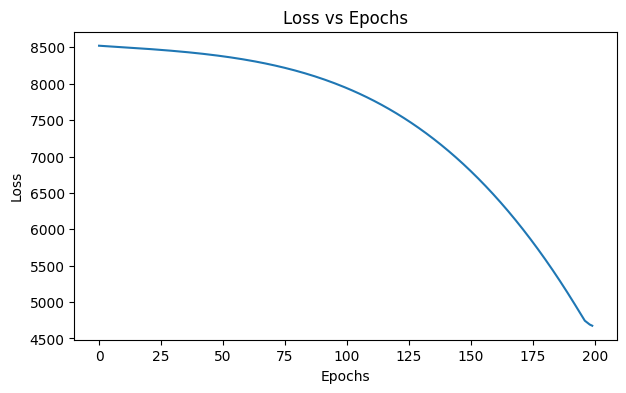

In [117]:
plt.figure(figsize=(7,4))
plt.plot(history_model2.history['loss' ])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

#### Example C

In [118]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

In [119]:
df = pd.read_csv('/content/sample_data/insurance_data.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [120]:
ct=make_column_transformer(
    (MinMaxScaler(),['age','bmi','children']),
    (OneHotEncoder(handle_unknown='ignore'),['sex','smoker','region'])
)

In [121]:
X=df.drop('charges',axis=1)
y=df['charges']

In [122]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [123]:
ct.fit(X_train)

ColumnTransformer(transformers=[('minmaxscaler', MinMaxScaler(),
                                 ['age', 'bmi', 'children']),
                                ('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['sex', 'smoker', 'region'])])

In [124]:
X_train_normal=ct.transform(X_train)
X_test_normal=ct.transform(X_test)

# means: “Make my training and test data ready for the neural network — in the same normalized way.”

In [125]:
# Non-normalized (Original) data
X_train

,age,sex,bmi,children,smoker,region
5,31,female,25.740,0,no,southeast
2,28,male,33.000,3,no,southeast
4,32,male,28.880,0,no,northwest
3,33,male,22.705,0,no,northwest


In [126]:
# Normalized data
X_train_normal

array([[0.6       , 0.2948033 , 0.        , 1.        , 0.        ,
        1.        , 0.        , 1.        ],
       [0.        , 1.        , 1.        , 0.        , 1.        ,
        1.        , 0.        , 1.        ],
       [0.8       , 0.59980573, 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ],
       [1.        , 0.        , 0.        , 0.        , 1.        ,
        1.        , 1.        , 0.        ]])

In [127]:
print("X-Train Shape",X_train.shape)
print("X-Train_Normal Shape",X_train_normal.shape)

X-Train Shape (4, 6)
X-Train_Normal Shape (4, 8)


In [128]:
tf.random.set_seed(42)
model3=tf.keras. Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model3.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.Adam(),
                        metrics=['mae'])

model3_history=model3.fit(X_train_normal,y_train,epochs=200,verbose=0)

In [129]:
model3.evaluate(X_test_normal,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 9156.9609 - mae: 9156.9609


[9156.9609375, 9156.9609375]